# Notebook to test and see the implementation of Hierarchical Refinement algorithm in jax

In [22]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

In [20]:
def create_points(
    rng= jax.random.key(0),       # seed for randomeness
    n: int = 100,       # number of points for X and Y
    d: int = 2,         # dimension vectors in X and Y
    ):
    """
    By default we use uniform distribution for a and b.
    """
    rngs = jax.random.split(rng, 4)
    x = jax.random.normal(rngs[0], (n, d)) + 10
    y = jax.random.normal(rngs[1], (n, d))
    a = jax.random.uniform(rngs[2], (n,))
    b = jax.random.uniform(rngs[3], (n,))
    a = a / jnp.sum(a)
    b = b / jnp.sum(b)
    return x, y, a, b

In [ ]:
def solve_low_rank_ot(
    x,
    y,
    a,
    b,
    epsilon=0.1,
    rank=2):

    geom = pointcloud.PointCloud(x, y, epsilon=epsilon)
    
    ot_prob = linear_problem.LinearProblem(geom, a, b)
    solver = sinkhorn_lr.LRSinkhorn(rank=rank)
    ot_lr = solver(ot_prob)
    return ot_lr

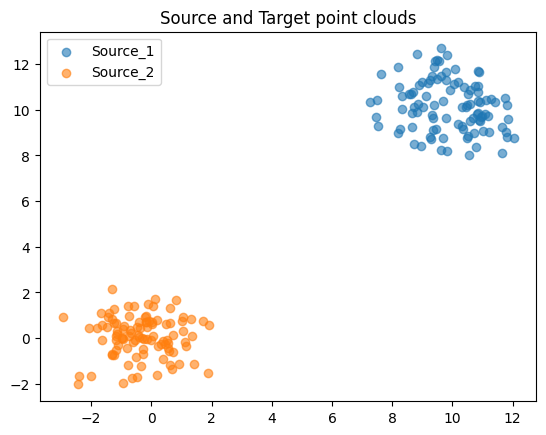

In [21]:
x, y, a, b = create_points( n=100, d=2)

c_src1 = "#1f77b4"   # bleu foncé
c_tgt1 = "#aec7e8"   # bleu clair

c_src2 = "#ff7f0e"   # orange foncé
c_tgt2 = "#ffbb78"   # orange clair


plt.scatter(x[:, 0], x[:, 1], color=c_src1, label="Source_1", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], color=c_src2, label="Source_2", alpha=0.6)

#plt.scatter(y1[:, 0], y1[:, 1], color=c_tgt1, label="Target_1", alpha=0.6)
#plt.scatter(y2[:, 0], y2[:, 1], color=c_tgt2, label="Target_2", alpha=0.6)

plt.legend()
plt.title("Source and Target point clouds")
plt.show()

In [ ]:
# Structure of the algorithm

# Load inputs : X, Y, Low_rank_solver, Rank schedule, base ranke

# Initialization step = 0 / Gamma = [[]] "couplings"

# Boucle While " tant que Card[X(t)] ou Card[Y(t)] pour X(t) et Y(t) in Gamma(t) > base rank"



